# 09 · Flux distribution and cumulative budget by variant

The half-hourly flux distribution and the running (cumulative) budget of the
quality-controlled flux per variant, the single place this comparison is produced.
It reads the flux processing chain output
([notebook 05](05_flux_processing_chain.ipynb)) and draws, per gas, one figure
with two rows and two panels: the QCL campaign (2021_1) on the left and the LGR
campaign (2021_2) on the right.

- **Top row, flux density distribution.** A lightly smoothed kernel density line of
  the half-hourly QC flux for each variant, with a dashed line at zero flux (after
  Vitale et al. 2024, Fig. 7). The covariance-maximization variants lose mass
  around zero, the "mirroring" bias (a bimodal dip); the PWB$_{OPT}$ variant, drawn
  filled as the reference, keeps it.
- **Bottom row, cumulative budget.** The running sum of the flux integrated into a
  cumulative mass; lines that fan apart mean the time-lag setting accumulates into
  a different total even after quality control.

The comparison is **paired**: within each analyzer the variants are aligned on the
timestamp index and only the half-hours where *every* variant has a
quality-controlled flux are kept, so both rows describe exactly the same samples.
Quality control removes a different set of half-hours per variant, so this
common-sample step is what makes the variants comparable. The panel title reports
the common-sample count (`n`).

One USTAR scenario is shown, `USTAR_SCENARIO`; re-run with a different value to
compare scenarios. Two figures are produced, one per gas, saved as
`figures/09_cumulative_{scenario}_{gas}.png`.

Inputs:
- `data/05-flux_processing_chain_parquet/` for the QC fluxes.

## Imports

In [21]:
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from diive.core.io.files import load_parquet

# White figure background (on screen and in saved PNGs).
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

NB_START = datetime.now()  # notebook start time (reported in the last cell)

## Configuration

`USTAR_SCENARIO` selects which of the three USTAR-filtered fluxes to sum. The QC
flux column in each `*_fpc.parquet` follows the chain's naming convention,
`{gas}_L3.1_L3.3_{scenario}_QCF`. All five variants per analyzer are summed,
including the PWB$_{OPT}$ variant (`*-5`).

In [22]:
FPCDIR = Path("../data/05-flux_processing_chain_parquet")  # QC fluxes
FIGDIR = Path("../figures")
FIGDIR.mkdir(parents=True, exist_ok=True)

YEAR = 2021
USTAR_SCENARIO = "CUT_50"  # one of CUT_16 / CUT_50 / CUT_84
DPI = 300

# Cumulative-mass conversion. The fluxes are half-hourly in nmol m-2 s-1, so each
# record integrates over RECORD_SECONDS. The per-record factor turns one
# nmol m-2 s-1 value into cumulative mass of the reported element:
#   nmol m-2 s-1  * RECORD_SECONDS  -> nmol m-2   (per 30-min record)
#                 * 1e-9            -> mol m-2
#                 * molar mass      -> g (element) m-2
# N2O is reported as N2O-N (two N atoms per molecule) and taken to kg ha-1;
# CH4 is reported as CH4-C and kept in g m-2.
RECORD_SECONDS = 1800     # 30-min flux averaging interval
M_N = 14.0067             # g mol-1, nitrogen
M_C = 12.011              # g mol-1, carbon
G_M2_TO_KG_HA = 10.0      # (g m-2) -> (kg ha-1): / 1000 g * 10000 m2

# The five time-lag variants per analyzer (the study variable).
ANALYZERS = {
    "QCL": ["QCL-1", "QCL-2", "QCL-3", "QCL-4", "QCL-5"],
    "LGR": ["LGR-1", "LGR-2", "LGR-3", "LGR-4", "LGR-5"],
}

# Per gas: flux column, pretty label, the cumulative-mass factor, and the unit of
# the cumulative series.
GASES = {
    "N2O": {"flux": "FN2O", "label": "N$_2$O",
            "factor": RECORD_SECONDS * 1e-9 * (2 * M_N) * G_M2_TO_KG_HA,
            "cum_unit": "kg N$_2$O-N ha$^{-1}$"},
    "CH4": {"flux": "FCH4", "label": "CH$_4$",
            "factor": RECORD_SECONDS * 1e-9 * M_C,
            "cum_unit": "g CH$_4$-C m$^{-2}$"},
}

# Meaningful variant names (by suffix number), matching notebook 08. Used as the
# legend labels instead of the bare codes. Method abbreviations follow Vitale
# et al. (2024): CM = covariance maximisation, CTR = constrained (narrow window),
# PWB_OPT = optimised pre-whitening with block-bootstrap.
VARIANT_NAMES = {
    1: "CM, wide, no default",
    2: "CM, wide, default",
    3: "CM$_{CTR}$, narrow, default",
    4: "Constant lag",
    5: "PWB$_{OPT}$",
}

# One color per variant suffix, shared across analyzers and gases. Paul Tol
# "bright" qualitative palette (colorblind-friendly, each hue distinct): blue,
# red, green, yellow, purple.
VAR_COLORS = {1: "#4477AA", 2: "#EE6677", 3: "#228833", 4: "#CCBB44", 5: "#AA3377"}


def qc_col(fluxvar, scenario):
    """Name of the USTAR-filtered, QCF-accepted flux column in the fpc output."""
    return f"{fluxvar}_L3.1_L3.3_{scenario}_QCF"


def variant_num(code):
    """Trailing variant number of a code, e.g. 'QCL-3' -> 3."""
    return int(code.split("-", 1)[1])


print(f"Cumulative QC flux, USTAR scenario: {USTAR_SCENARIO}")

Cumulative QC flux, USTAR scenario: CUT_50


## Load the QC fluxes

For each variant and gas, the QC flux is pulled from its `*_fpc.parquet` (the
single `USTAR_SCENARIO` column), restricted to the analysis year.

In [23]:
all_codes = [c for codes in ANALYZERS.values() for c in codes]

qcflux = {}  # (code, gas-name) -> QC flux series for the chosen USTAR scenario
for code in all_codes:
    for gas, v in GASES.items():
        df = load_parquet(filepath=str(FPCDIR / f"{code}_{v['flux']}_fpc.parquet"))
        df = df.loc[df.index.year == YEAR]
        qcflux[(code, gas)] = df[qc_col(v["flux"], USTAR_SCENARIO)]

for code in all_codes:
    n = int(qcflux[(code, "N2O")].notna().sum())
    print(f"{code}: {n} valid QC N2O ({USTAR_SCENARIO})")

> Loaded .parquet file ..\data\05-flux_processing_chain_parquet\QCL-1_FN2O_fpc.parquet (0.005 seconds).

> Loaded .parquet file ..\data\05-flux_processing_chain_parquet\QCL-1_FCH4_fpc.parquet (0.004 seconds).

> Loaded .parquet file ..\data\05-flux_processing_chain_parquet\QCL-2_FN2O_fpc.parquet (0.005 seconds).

> Loaded .parquet file ..\data\05-flux_processing_chain_parquet\QCL-2_FCH4_fpc.parquet (0.005 seconds).

> Loaded .parquet file ..\data\05-flux_processing_chain_parquet\QCL-3_FN2O_fpc.parquet (0.004 seconds).

...

> Loaded .parquet file ..\data\05-flux_processing_chain_parquet\LGR-4_FN2O_fpc.parquet (0.004 seconds).

> Loaded .parquet file ..\data\05-flux_processing_chain_parquet\LGR-4_FCH4_fpc.parquet (0.005 seconds).

> Loaded .parquet file ..\data\05-flux_processing_chain_parquet\LGR-5_FN2O_fpc.parquet (0.004 seconds).

> Loaded .parquet file ..\data\05-flux_processing_chain_parquet\LGR-5_FCH4_fpc.parquet (0.005 seconds).

QCL-1: 6270 valid QC N2O (CUT_50)
QCL-2: 6206 valid QC N2O (CUT_50)
QCL-3: 5468 valid QC N2O (CUT_50)
QCL-4: 5314 valid QC N2O (CUT_50)
QCL-5: 5313 valid QC N2O (CUT_50)
LGR-1: 5067 valid QC N2O (CUT_50)
LGR-2: 5029 valid QC N2O (CUT_50)
LGR-3: 4831 valid QC N2O (CUT_50)
LGR-4: 4362 valid QC N2O (CUT_50)
LGR-5: 4339 valid QC N2O (CUT_50)


## Flux distribution and cumulative budget over common samples

One figure per gas, two rows by two panels: QCL (left) and LGR (right). Within
each analyzer the variants are aligned and reduced to their common samples, and
both rows are drawn from that same paired set.

The **top row** shows the half-hourly flux density distribution per variant, a
lightly smoothed kernel density line (robust, undersmoothed bandwidth) over a
zoomed flux range (median +/- a few IQR); watch for the covariance-maximization
variants losing mass around zero relative to the filled PWB$_{OPT}$ reference. The
**bottom row** integrates the same half-hourly flux over time into a cumulative
mass (N2O as kg N2O-N ha⁻¹, CH4 as g CH4-C m⁻²); each variant's **overall total**
(the final cumulative value) is shown in the legend, so the budget differences are
read directly.

Two tuning knobs on the density row: `DENS_IQR` sets how far the x-range zooms out,
and `KDE_BW_FACTOR` sets the smoothing (smaller = sharper; lower it further if the
near-zero dip is still smeared).

Saved ..\figures\09_cumulative_cut_50_n2o.png


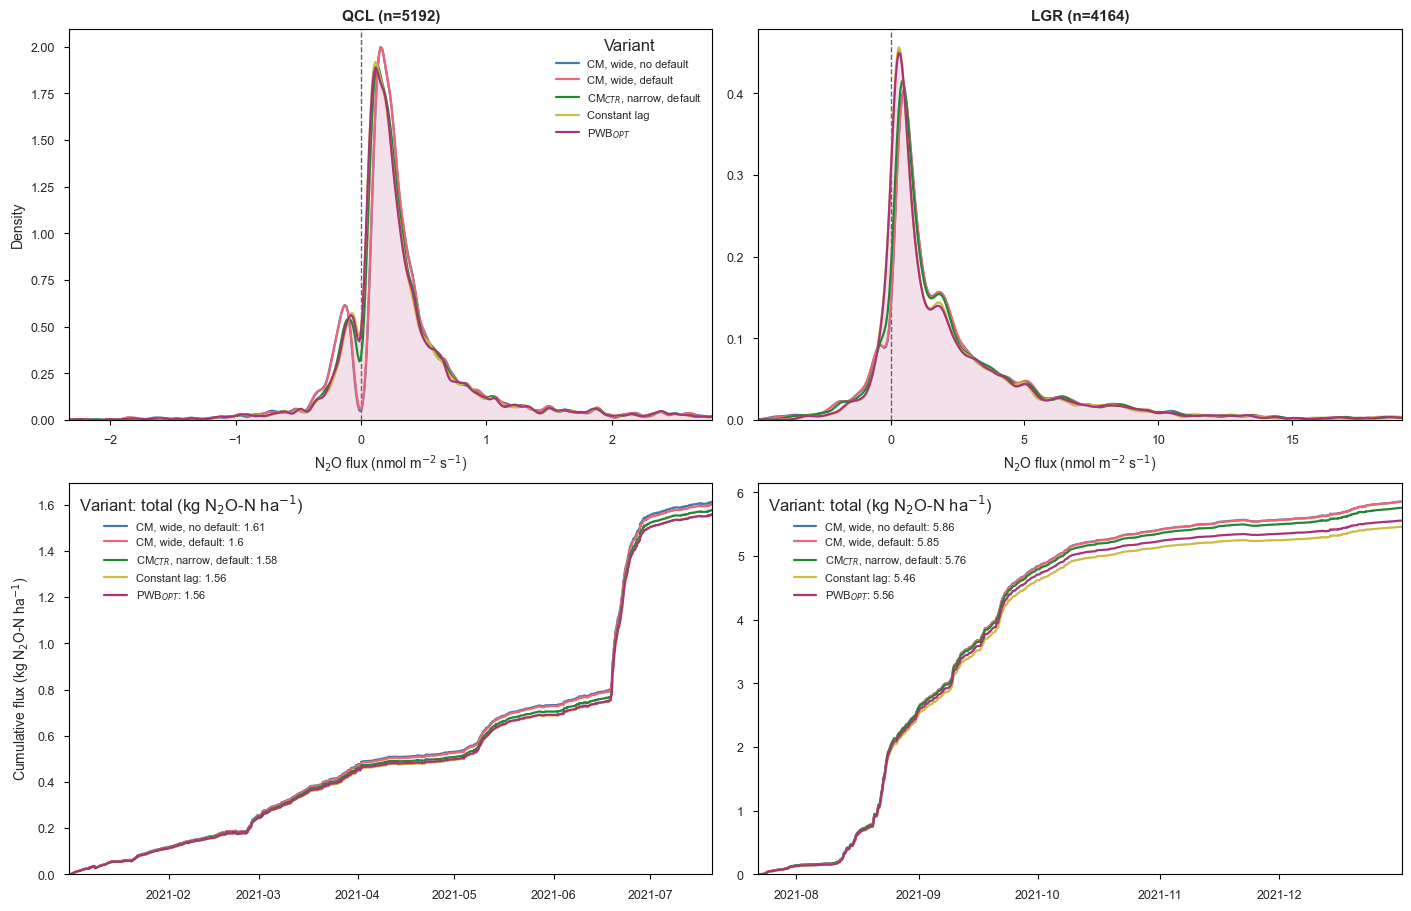

Saved ..\figures\09_cumulative_cut_50_ch4.png


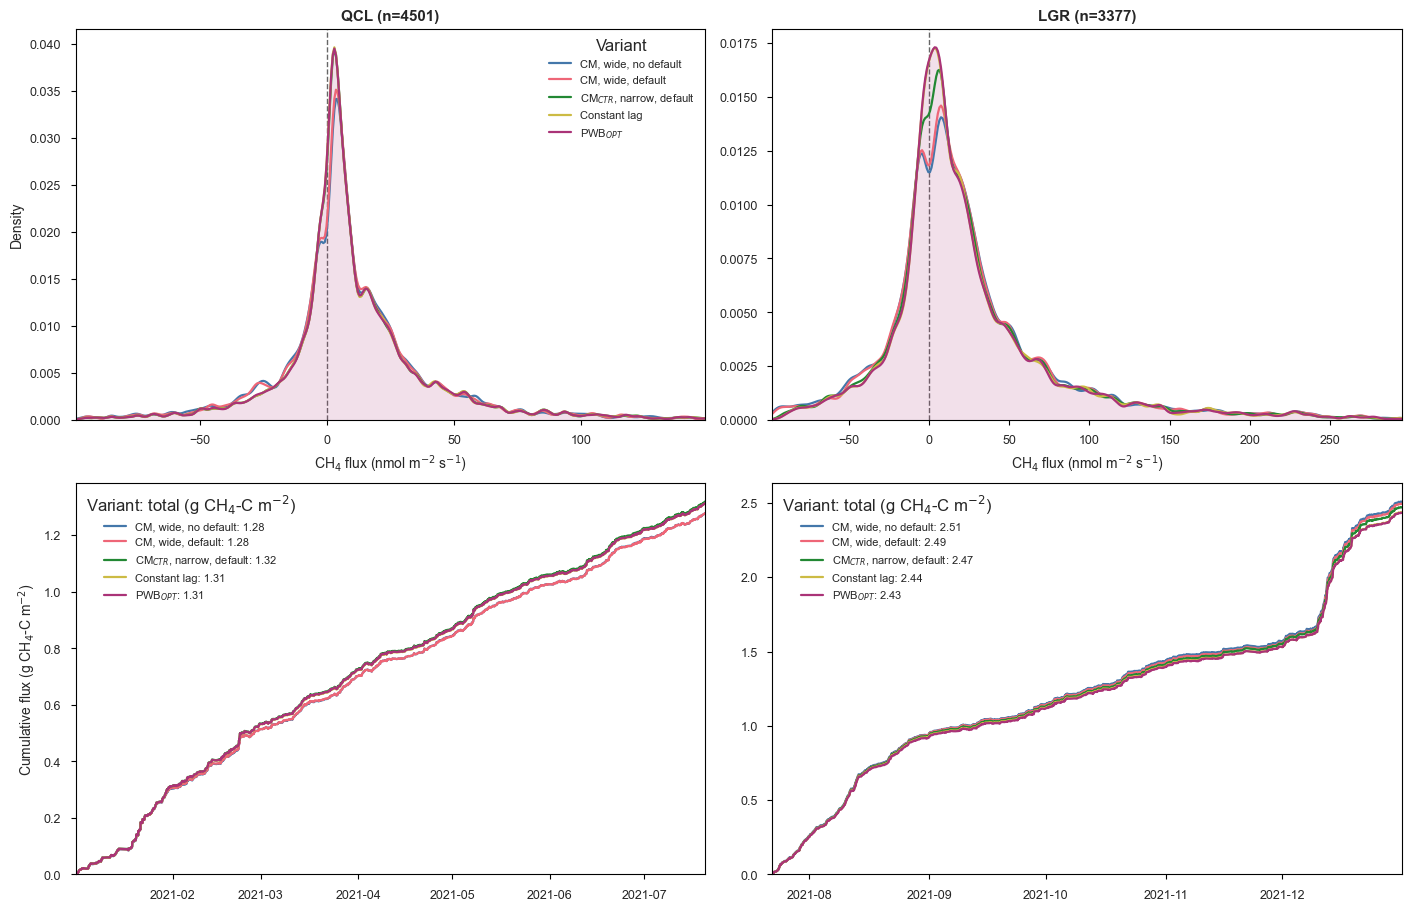

In [24]:
def style_axes(ax):
    """Black spines, short outward ticks, no grid."""
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(0.8)
    ax.tick_params(which="major", length=3.5, width=0.8, direction="out", color="black")


DENS_IQR = 6          # density x-range: median +/- this many IQR of the pooled flux
KDE_N = 400           # points on the density x-grid
KDE_BW_FACTOR = 0.5   # smoothing: smaller = sharper (resolves the near-zero dip)


def flux_kde(x, xs):
    """KDE of a flux sample on xs with a robust, lightly smoothed bandwidth. scipy's
    default scales the bandwidth by the standard deviation, which the heavy-tailed
    covariance-maximization variants inflate, smearing away the sharp near-zero
    mirroring dip. Basing the bandwidth on min(std, IQR/1.349) and undersmoothing
    (KDE_BW_FACTOR < 1) keeps that bimodal structure visible."""
    x = np.asarray(x, dtype=float)
    std = float(x.std())
    q75, q25 = np.percentile(x, [75, 25])
    robust = min(std, (q75 - q25) / 1.349) if q75 > q25 else std
    if std == 0 or robust == 0:
        robust = std = 1.0  # degenerate guard (does not occur for real flux)
    bw = KDE_BW_FACTOR * x.size ** (-1 / 5) * robust / std  # effective bw = factor*robust
    return gaussian_kde(x, bw_method=bw)(xs)


for gas, v in GASES.items():
    factor, cum_unit, glabel = v["factor"], v["cum_unit"], v["label"]
    fig, axes = plt.subplots(2, len(ANALYZERS), figsize=(14, 9),
                             constrained_layout=True, squeeze=False)
    for ci, (analyzer, codes) in enumerate(ANALYZERS.items()):
        ax_den, ax_cum = axes[0, ci], axes[1, ci]

        # Align the variants and keep only the common (paired) samples, so the
        # density distributions (top) and the cumulative budgets (bottom) describe
        # exactly the same set of half-hours.
        frame = pd.DataFrame({code: qcflux[(code, gas)] for code in codes})
        common = frame.dropna(how="any")

        # Row 1: flux density distribution per variant, a lightly smoothed kernel
        # density line over the common samples (cf. Vitale et al. 2024, Fig. 7). A
        # dashed line marks zero flux; the covariance-maximization variants lose
        # mass around zero (the "mirroring" bias, a bimodal dip) while the PWB_OPT
        # variant, drawn filled as the reference, keeps it. The x-range zooms to the
        # bulk (median +/- DENS_IQR * IQR) and flux_kde undersmooths, so the dip is
        # not smeared out by the heavy-tailed CM variants.
        vals = common.to_numpy().ravel()
        med = float(np.median(vals))
        q75, q25 = np.percentile(vals, [75, 25])
        iqr = q75 - q25
        lo = max(med - DENS_IQR * iqr, float(vals.min()))
        hi = min(med + DENS_IQR * iqr, float(vals.max()))
        xs = np.linspace(lo, hi, KDE_N)
        ax_den.axvline(0, color="0.4", ls="--", lw=1.0, zorder=0.5)
        for code in codes:
            num = variant_num(code)
            dens = flux_kde(common[code].to_numpy(), xs)
            if num == 5:  # PWB_OPT: fill as the reference method
                ax_den.fill_between(xs, 0, dens, color=VAR_COLORS[num], alpha=0.15, lw=0)
            ax_den.plot(xs, dens, lw=1.6, color=VAR_COLORS[num], label=VARIANT_NAMES[num])
        ax_den.set_xlim(lo, hi)
        ax_den.set_ylim(bottom=0)
        ax_den.set_xlabel(f"{glabel} flux (nmol m$^{{-2}}$ s$^{{-1}}$)")
        ax_den.set_title(f"{analyzer} (n={common.shape[0]})", fontweight="bold")
        style_axes(ax_den)

        # Row 2: cumulative budget per variant over the same common samples,
        # integrated from the half-hourly flux into a cumulative mass. Each
        # variant's overall total (final cumulative value) is shown in the legend.
        cum = common.cumsum() * factor
        for code in codes:
            num = variant_num(code)
            total = cum[code].iloc[-1] if len(cum) else float("nan")
            ax_cum.plot(cum.index, cum[code], lw=1.6, color=VAR_COLORS[num],
                        label=f"{VARIANT_NAMES[num]}: {total:.3g}")
        if len(cum.index):
            ax_cum.set_xlim(cum.index.min(), cum.index.max())
        ax_cum.set_ylim(bottom=0)  # start the y-axis at exactly zero
        style_axes(ax_cum)
        ax_cum.legend(fontsize=8, loc="upper left", title=f"Variant: total ({cum_unit})")

    axes[0, 0].set_ylabel("Density")
    axes[0, 0].legend(fontsize=8, loc="upper right", title="Variant")
    axes[1, 0].set_ylabel(f"Cumulative flux ({cum_unit})")
    out = FIGDIR / f"09_cumulative_{USTAR_SCENARIO.lower()}_{gas.lower()}.png"
    fig.savefig(out, dpi=DPI, bbox_inches="tight")
    print(f"Saved {out}")
    plt.show()

## Runtime

In [25]:
NB_END = datetime.now()
print(f"Start:    {NB_START:%Y-%m-%d %H:%M:%S}")
print(f"End:      {NB_END:%Y-%m-%d %H:%M:%S}")
print(f"Runtime:  {NB_END - NB_START}")

Start:    2026-07-12 01:24:22
End:      2026-07-12 01:24:25
Runtime:  0:00:02.868674
